# Traffic Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import holidays
from matplotlib.colors import LinearSegmentedColormap, to_hex
from sqlalchemy import create_engine, text
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

DB_USER = "admin"
DB_PASS = "admin"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "pap"

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL, future=True)

def make_gradient(start_hex, end_hex, n):
    cmap = LinearSegmentedColormap.from_list("custom_gradient", [start_hex, end_hex], N=max(n, 2))
    if n <= 1:
        return [start_hex]
    return [to_hex(cmap(i / (n - 1))) for i in range(n)]

TRAFFIC_COLOR    = "#4a6fa5"
TRAFFIC_PRED     = "#5aa897"
TRAFFIC_ANOMALY  = "#c97b63"

MONTH_GRADIENT = make_gradient("#dbe8f5", "#6b8fbf", 12)
ANOMALY_MONTH_GRADIENT = make_gradient("#dff3ee", "#5aa897", 12)

MONTH_NAMES = {
    1:"Jan",
    2:"Feb",
    3:"Mar",
    4:"Apr",
    5:"May",
    6:"Jun",
    7:"Jul",
    8:"Aug",
    9:"Sep",
    10:"Oct",
    11:"Nov",
    12:"Dec"
}

EURO_COLOR_MAP = {
    "EURO0": "#c26a5a",
    "EURO1": "#d09162",
    "EURO2": "#d8b26a",
    "EURO3": "#9fb06b",
    "EURO4": "#6da5a5",
    "EURO5": "#5b86b1",
    "EURO6": "#5d9b74",
    "NC": "#b3b3b3",
}

FUEL_COLOR_MAP = {
    "BENZINA": "#c8848a",
    "DIESEL": "#6ca67a",
    "ELETTRICO": "#6f92c9",
    "IBRIDO": "#d2a06b",
    "GPL": "#9c85bf",
    "METANO": "#78b9bf",
    "IDROGENO": "#c98ec9",
    "NC": "#b3b3b3",
}

IMGS_DIR = os.path.join('..', 'docs', 'images', '3_traffic')
TABS_DIR = os.path.join('..', 'docs', 'tables', '3_traffic')
os.makedirs(IMGS_DIR, exist_ok=True)
os.makedirs(TABS_DIR, exist_ok=True)



# Fleet Composition Analysis

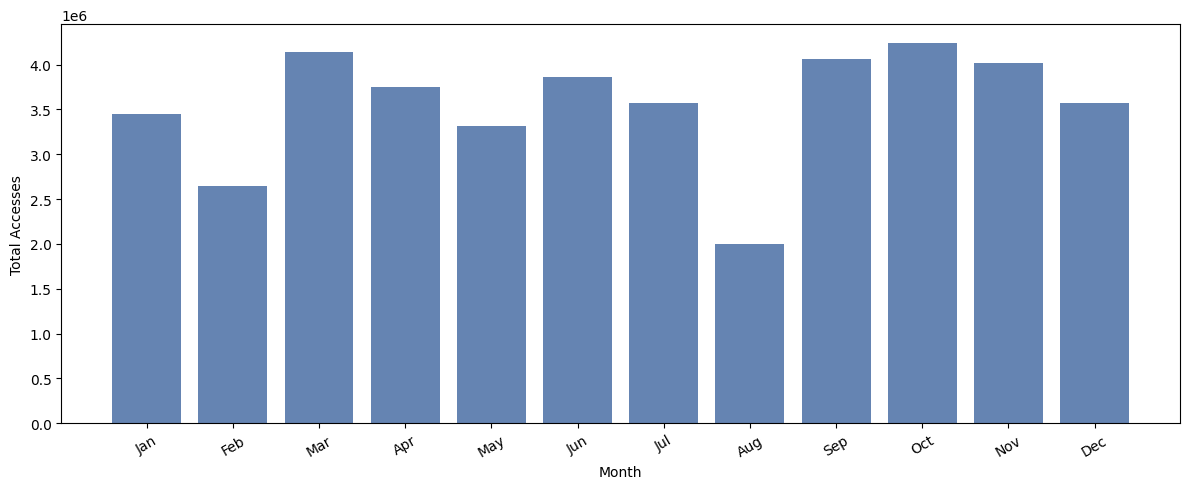

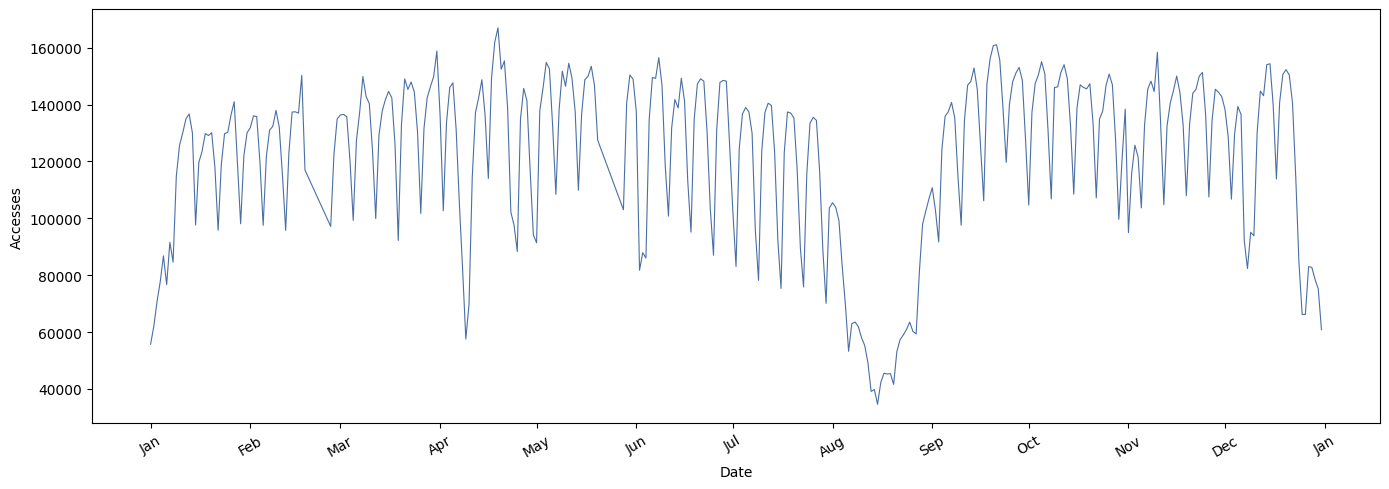

In [2]:
SQL_MONTH_TOTAL = text("""
SELECT d.month, SUM(ga.count) AS month_total
FROM pap.gate_access_ft ga
JOIN pap.date_dt d ON d.date_id = ga.date_id
GROUP BY d.month
ORDER BY d.month;
""")

SQL_DAILY_TOTAL = text("""
SELECT d.date AS day, SUM(ga.count) AS total_accesses
FROM pap.gate_access_ft ga
JOIN pap.date_dt d ON d.date_id = ga.date_id
GROUP BY d.date
ORDER BY d.date;
""")

with engine.connect() as con:
    monthly_df = pd.read_sql(SQL_MONTH_TOTAL, con)
    daily_df   = pd.read_sql(SQL_DAILY_TOTAL, con)

monthly_df["month"] = monthly_df["month"].astype(int)
daily_df["day"] = pd.to_datetime(daily_df["day"])
daily_df = daily_df.set_index("day").sort_index()

monthly_df["month_label"] = monthly_df["month"].map(MONTH_NAMES)

# Monthly bar
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.bar(monthly_df["month_label"], monthly_df["month_total"], color=TRAFFIC_COLOR, alpha=0.85)
ax.set_xlabel("Month")
ax.set_ylabel("Total Accesses")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'total_accesses_monthly.png'), dpi=150, bbox_inches='tight')
plt.show()

# Daily line
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(daily_df.index, daily_df["total_accesses"], linewidth=0.8, color=TRAFFIC_COLOR)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlabel("Date")
ax.set_ylabel("Accesses")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'total_accesses_daily.png'), dpi=150, bbox_inches='tight')
plt.show()


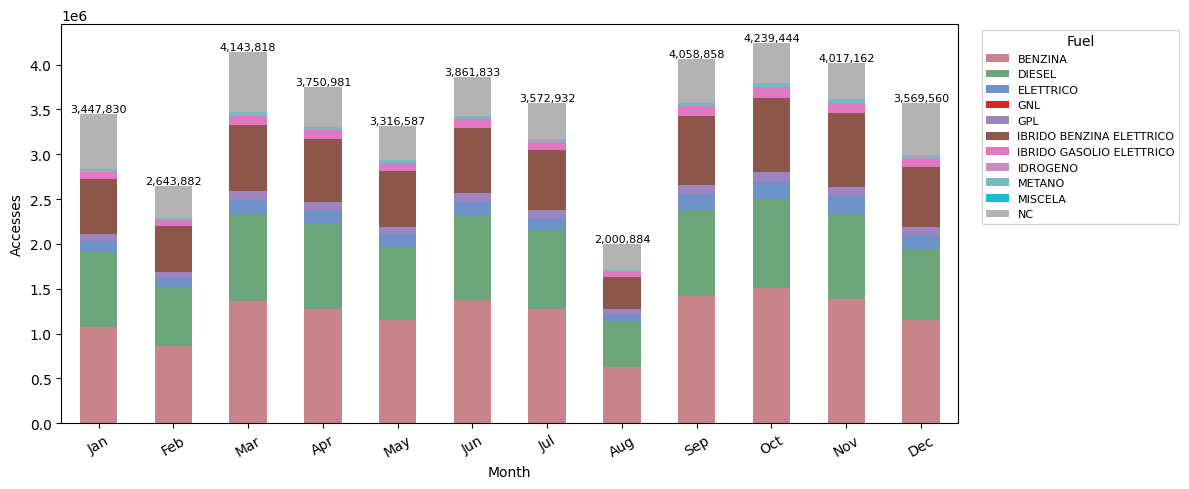

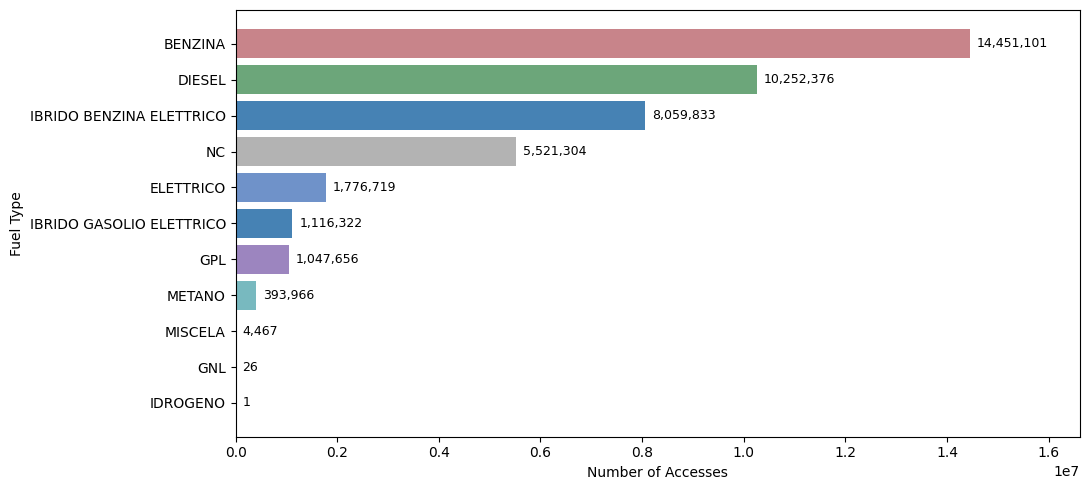

In [3]:
SQL_MONTH_FUEL = text("""
WITH monthly_fuel AS (
  SELECT d.month, v.fuel, SUM(ga.count) AS accesses
  FROM pap.gate_access_ft ga
  JOIN pap.date_dt d ON d.date_id = ga.date_id
  JOIN pap.vehicle_dt v ON v.vehicle_id = ga.vehicle_id
  GROUP BY d.month, v.fuel
)
SELECT month, 
      fuel,
      accesses,
      ROUND(100.0 * accesses / NULLIF(SUM(accesses) OVER (PARTITION BY month), 0), 2) AS pct
FROM monthly_fuel
ORDER BY month, accesses DESC;
""")

with engine.connect() as con:
    df_fuel = pd.read_sql(SQL_MONTH_FUEL, con)

df_fuel["month"] = df_fuel["month"].astype(int)
df_fuel = df_fuel.dropna(subset=["fuel"]).sort_values(["month", "fuel"]).reset_index(drop=True)
pv_fuel = df_fuel.pivot_table(index="month", columns="fuel", values="accesses", aggfunc="sum", fill_value=0).sort_index()
pv_fuel_pct = pv_fuel.div(pv_fuel.sum(axis=1), axis=0) * 100

fuel_totals = df_fuel.groupby("fuel")["accesses"].sum().sort_values(ascending=True)
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
stacked_fuel_colors = [
    FUEL_COLOR_MAP.get(str(col), default_colors[i % len(default_colors)])
    for i, col in enumerate(pv_fuel.columns)
]

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
pv_fuel.plot(kind="bar", stacked=True, ax=ax, color=stacked_fuel_colors)
ax.set_xlabel("Month")
ax.set_ylabel("Accesses")
ax.set_xticklabels([MONTH_NAMES.get(int(m), m) for m in pv_fuel.index], rotation=30)
ax.legend(title="Fuel", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
for i, total in enumerate(pv_fuel.sum(axis=1)):
    ax.annotate(f"{total:,.0f}", xy=(i, total), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'fleet_composition_by_fuel_monthly.png'), dpi=150, bbox_inches='tight')
plt.show()

hbar_fuel_colors = [FUEL_COLOR_MAP.get(str(f), "steelblue") for f in fuel_totals.index]
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
bars = ax.barh(fuel_totals.index, fuel_totals.values, color=hbar_fuel_colors)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in fuel_totals.values], padding=5, fontsize=9)
ax.set_xlabel("Number of Accesses")
ax.set_ylabel("Fuel Type")
ax.margins(x=0.15)
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'total_accesses_by_fuel.png'), dpi=150, bbox_inches='tight')
plt.show()


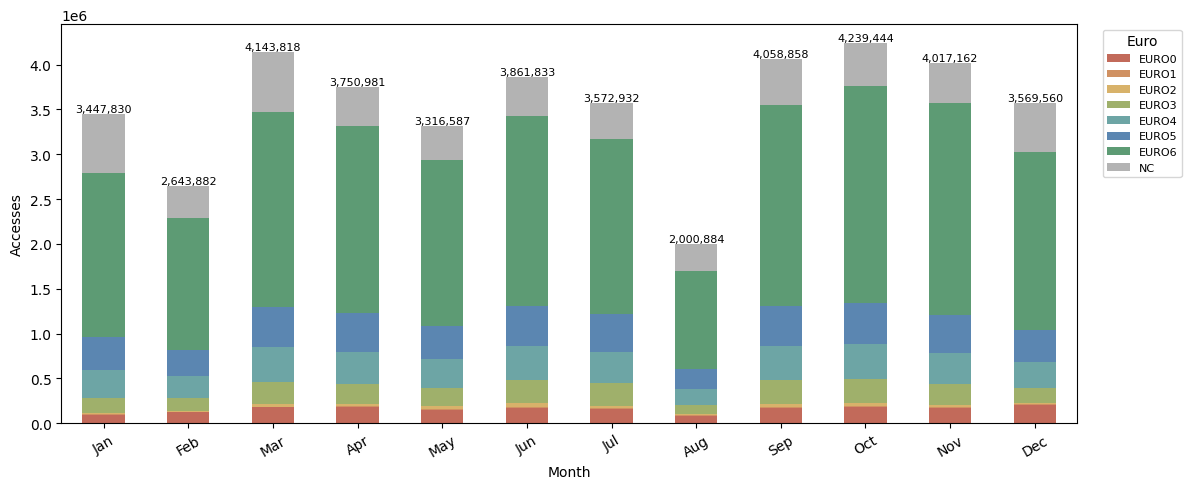

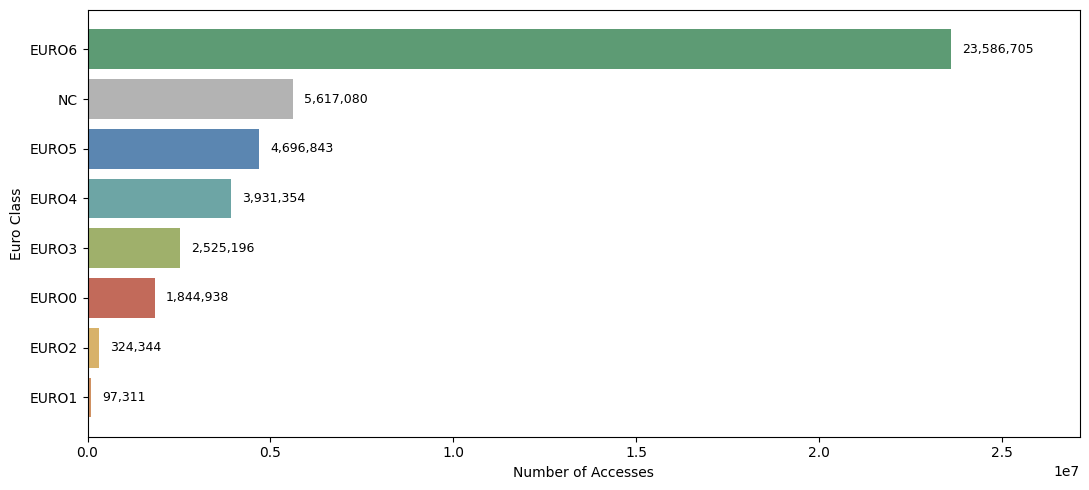

In [4]:
SQL_MONTH_EURO = text("""
WITH monthly_euro AS (
  SELECT 
    d.month, 
    v.euro, 
    SUM(ga.count) AS accesses
  FROM pap.gate_access_ft ga
  JOIN pap.date_dt d ON d.date_id = ga.date_id
  JOIN pap.vehicle_dt v ON v.vehicle_id = ga.vehicle_id
  GROUP BY d.month, v.euro
)
SELECT month, euro, accesses,
    ROUND(100.0 * accesses / SUM(accesses) OVER (PARTITION BY month), 2) AS pct
FROM monthly_euro
ORDER BY month, euro;
""")

SQL_EURO_TOTAL = text("""
  SELECT v.euro, SUM(ga.count) AS total_accesses
  FROM pap.gate_access_ft ga
  JOIN pap.vehicle_dt v ON v.vehicle_id = ga.vehicle_id
  GROUP BY v.euro
  ORDER BY total_accesses DESC;
""")

with engine.connect() as con:
    df_euro = pd.read_sql(SQL_MONTH_EURO, con)
    df_etot = pd.read_sql(SQL_EURO_TOTAL, con)

df_euro["month"] = df_euro["month"].astype(int)
df_euro = df_euro.dropna(subset=["euro"]).sort_values(["month", "euro"]).reset_index(drop=True)
pv_euro = df_euro.pivot_table(index="month", columns="euro", values="accesses", aggfunc="sum", fill_value=0).sort_index()
pv_euro_pct = pv_euro.div(pv_euro.sum(axis=1), axis=0) * 100
euro_totals = df_etot.set_index("euro")["total_accesses"].sort_values(ascending=True)

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
stacked_euro_colors = [
    EURO_COLOR_MAP.get(str(col), default_colors[i % len(default_colors)])
    for i, col in enumerate(pv_euro.columns)
]

# Monthly Fleet Composition by Euro Class
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
pv_euro.plot(kind="bar", stacked=True, ax=ax, color=stacked_euro_colors)
ax.set_xlabel("Month")
ax.set_ylabel("Accesses")
ax.set_xticklabels([MONTH_NAMES.get(int(m), m) for m in pv_euro.index], rotation=30)
ax.legend(title="Euro", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
month_totals = pv_euro.sum(axis=1)
for i, total in enumerate(month_totals):
    ax.annotate(f"{total:,.0f}", xy=(i, total), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'fleet_composition_by_euro_monthly.png'), dpi=150, bbox_inches='tight')
plt.show()

# Total Accesses by Euro Class
hbar_euro_colors = [EURO_COLOR_MAP.get(str(cls), "steelblue") for cls in euro_totals.index]
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
bars = ax.barh(euro_totals.index, euro_totals.values, color=hbar_euro_colors)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in euro_totals.values], padding=8, fontsize=9)
ax.set_xlabel("Number of Accesses")
ax.set_ylabel("Euro Class")
ax.margins(x=0.15)
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'total_accesses_by_euro.png'), dpi=150, bbox_inches='tight')
plt.show()


# Weekly Analysis

In [5]:
SQL_DAILY_TOTAL = text("""
SELECT d.date AS day, SUM(ga.count) AS total_accesses
FROM pap.gate_access_ft ga
JOIN pap.date_dt d ON d.date_id = ga.date_id
GROUP BY d.date
ORDER BY d.date;
""")

with engine.connect() as con:
    daily_df = pd.read_sql(SQL_DAILY_TOTAL, con)

daily_df["day"] = pd.to_datetime(daily_df["day"])
daily_df = daily_df.set_index("day").sort_index()

reg_df = daily_df.copy()
reg_df.columns = ["y"]

for lag in [1, 2, 3, 7]:
    reg_df[f"lag_{lag}"] = reg_df["y"].shift(lag)

reg_df["roll7_mean"] = reg_df["y"].shift(1).rolling(7).mean()
reg_df["roll7_std"] = reg_df["y"].shift(1).rolling(7).std()
reg_df["dow"] = reg_df.index.dayofweek
reg_df["month"] = reg_df.index.month
reg_df["is_weekend"] = (reg_df["dow"] >= 5).astype(int)

years = reg_df.index.year.unique().tolist()
it_holidays = holidays.Italy(years=years, subdiv="MI")
reg_df["is_holiday"] = reg_df.index.map(lambda d: int(d in it_holidays))

reg_df["is_bridge"] = (
    (reg_df["is_holiday"].shift(1, fill_value=0) | reg_df["is_weekend"].shift(1, fill_value=0)) &
    (reg_df["is_holiday"].shift(-1, fill_value=0) | reg_df["is_weekend"].shift(-1, fill_value=0)) &
    (reg_df["is_weekend"] == 0) &
    (reg_df["is_holiday"] == 0)
).astype(int)

reg_df = reg_df.dropna()

FEATURE_COLS = [
    "lag_1", "lag_2", "lag_3", "lag_7",
    "roll7_mean", "roll7_std",
    "dow", "month",
    "is_weekend", "is_holiday", "is_bridge",
]

X = reg_df[FEATURE_COLS]
y = reg_df["y"]

print(f"Dataset: {reg_df.index[0].date()} - {reg_df.index[-1].date()}")
print(f"Available days: {len(reg_df)}")
print(f"Holiday days: {reg_df['is_holiday'].sum()}")
print(f"Bridge days:  {reg_df['is_bridge'].sum()}")


Dataset: 2023-01-08 - 2023-12-31
Available days: 344
Holiday days: 12
Bridge days:  2


Execution GridSearchCV for explore hyperparameters...
Fitting 11 folds for each of 45 candidates, totalling 495 fits
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 250}

Execution Time Series Cross-Validation con i migliori parametri...
Fold 1: Train on 36 gg | Test on 28 gg (Feb 13 to Mar 19)
Fold 2: Train on 64 gg | Test on 28 gg (Mar 20 to Apr 16)
Fold 3: Train on 92 gg | Test on 28 gg (Apr 17 to May 14)
Fold 4: Train on 120 gg | Test on 28 gg (May 15 to Jun 18)
Fold 5: Train on 148 gg | Test on 28 gg (Jun 19 to Jul 16)
Fold 6: Train on 176 gg | Test on 28 gg (Jul 17 to Aug 13)
Fold 7: Train on 204 gg | Test on 28 gg (Aug 14 to Sep 10)
Fold 8: Train on 232 gg | Test on 28 gg (Sep 11 to Oct 08)
Fold 9: Train on 260 gg | Test on 28 gg (Oct 09 to Nov 05)
Fold 10: Train on 288 gg | Test on 28 gg (Nov 06 to Dec 03)
Fold 11: Train on 316 gg | Test on 28 gg (Dec 04 to Dec 31)

Metrics
MAE: 10,334 accesses/day
RMSE: 15,529 accesses/day
MAPE: 11.0 %
R2: 0.731

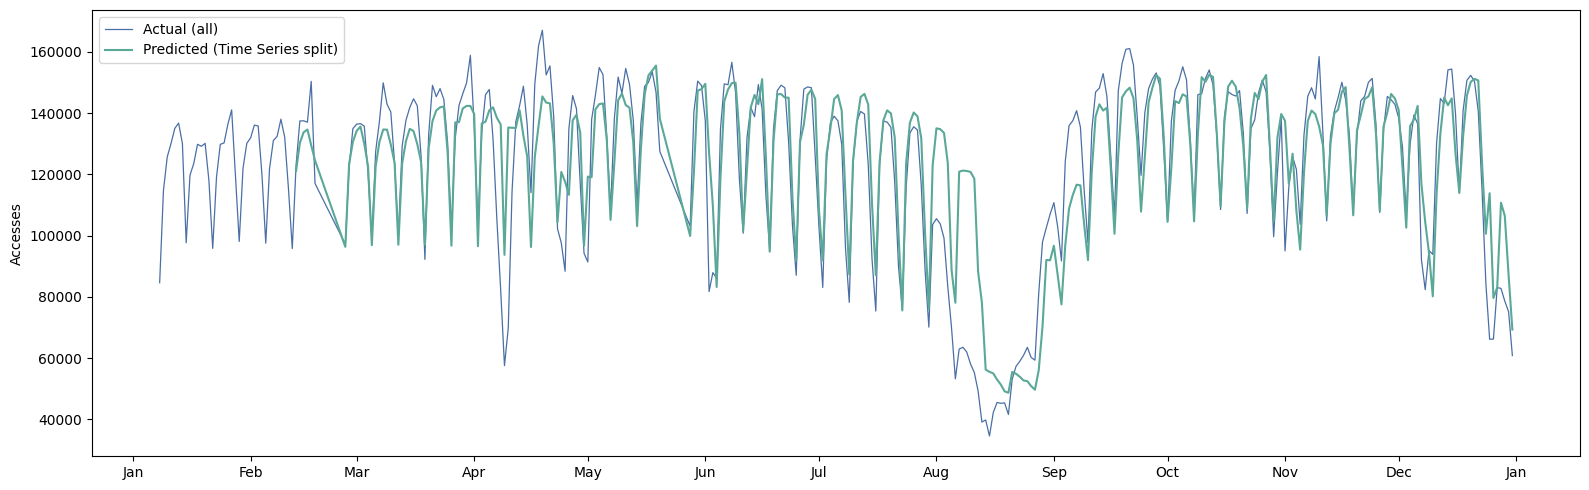

In [6]:
param_grid = {
    'n_estimators': [100, 250, 500],
    'max_depth': [3, 5, 10, 15, 20],
    'min_samples_leaf': [2, 5, 10]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
tscv = TimeSeriesSplit(n_splits=11)

print("Execution GridSearchCV for explore hyperparameters...")
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)
print(f"Best parameters found: {grid_search.best_params_}")

rf = grid_search.best_estimator_

y_pred_all = pd.Series(index=y.index, dtype=float)

print("\nExecution Time Series Cross-Validation con i migliori parametri...")
for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    
    rf.fit(X_train_fold, y_train_fold)
    y_pred_all.iloc[test_index] = rf.predict(X_test_fold)
    
    start_test = X_test_fold.index[0].strftime("%b %d")
    end_test = X_test_fold.index[-1].strftime("%b %d")
    print(f"Fold {fold}: Train on {len(X_train_fold)} gg | Test on {len(X_test_fold)} gg ({start_test} to {end_test})")

y_pred = y_pred_all.dropna()
y_test = y.loc[y_pred.index]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"\nMetrics")
print(f"MAE: {mae:,.0f} accesses/day")
print(f"RMSE: {rmse:,.0f} accesses/day")
print(f"MAPE: {mape:.1f} %")
print(f"R2: {r2:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(16, 5))

ax.plot(reg_df.index, reg_df["y"], color=TRAFFIC_COLOR, linewidth=0.9, label="Actual (all)")
ax.plot(y_pred.index, y_pred, color=TRAFFIC_PRED, linewidth=1.5, label="Predicted (Time Series split)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel("Accesses")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'traffic_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()


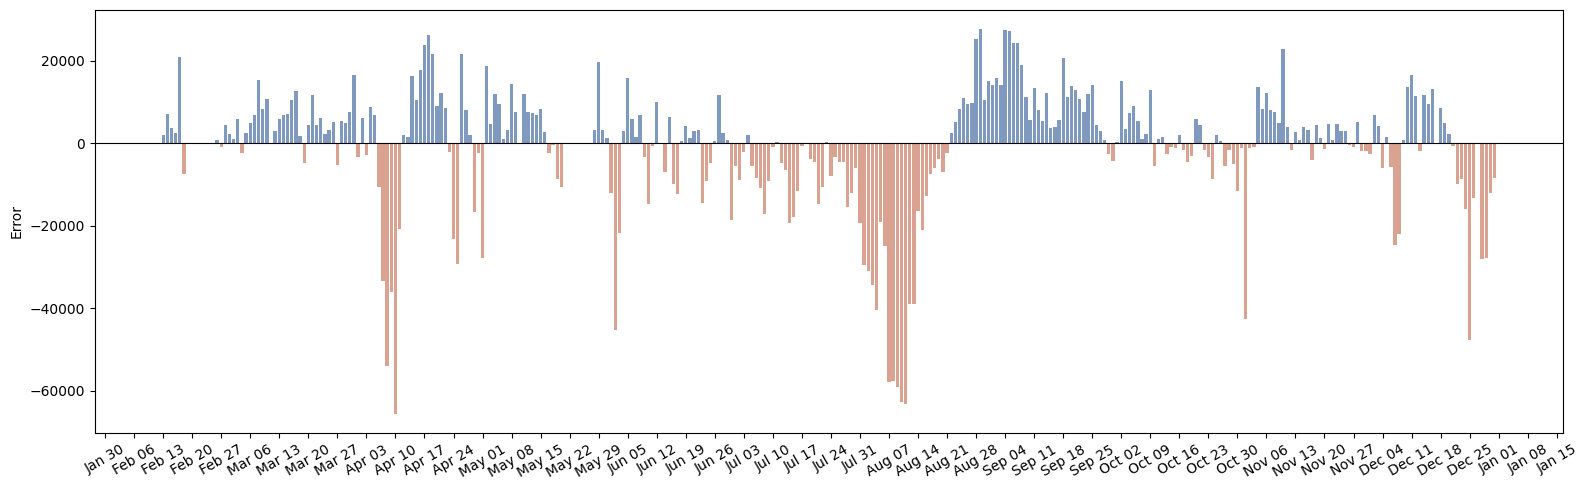

MAE=10,334  RMSE=15,529  R²=0.731


In [7]:
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 1, figsize=(16, 5))

ax.bar(residuals.index, residuals, color=np.where(residuals >= 0, TRAFFIC_COLOR, TRAFFIC_ANOMALY), width=0.8, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Error")

plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'traffic_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.3f}")


# Anomalys Analysis

In [8]:
anom_df = daily_df.copy()
anom_df.columns = ["traffic"]

# CONTAMINATION = 'auto'
CONTAMINATION = 0.05
iso = IsolationForest(n_estimators=200, contamination=CONTAMINATION, random_state=42)
anom_df["if_score"]   = iso.fit_predict(anom_df[["traffic"]])   # -1 = anomaly
anom_df["if_outlier"] = anom_df["if_score"] == -1

if_outliers = anom_df[anom_df["if_outlier"]].copy()
print(f"\nIsolation Forest outliers: {len(if_outliers)} days")
display(if_outliers[["traffic", "if_score"]].assign(
    traffic=if_outliers["traffic"].map("{:,.0f}".format)
))
if_outliers[["traffic", "if_score"]].to_csv(os.path.join(TABS_DIR, 'anomaly_days.csv'))



Isolation Forest outliers: 18 days


,traffic,if_score
day,,
2023-03-31,"158,830",-1
2023-04-18,"161,995",-1
2023-04-19,"167,006",-1
2023-08-06,"53,215",-1
2023-08-11,"55,278",-1
2023-08-12,"49,235",-1
2023-08-13,"39,110",-1
2023-08-14,"39,785",-1
2023-08-15,"34,559",-1


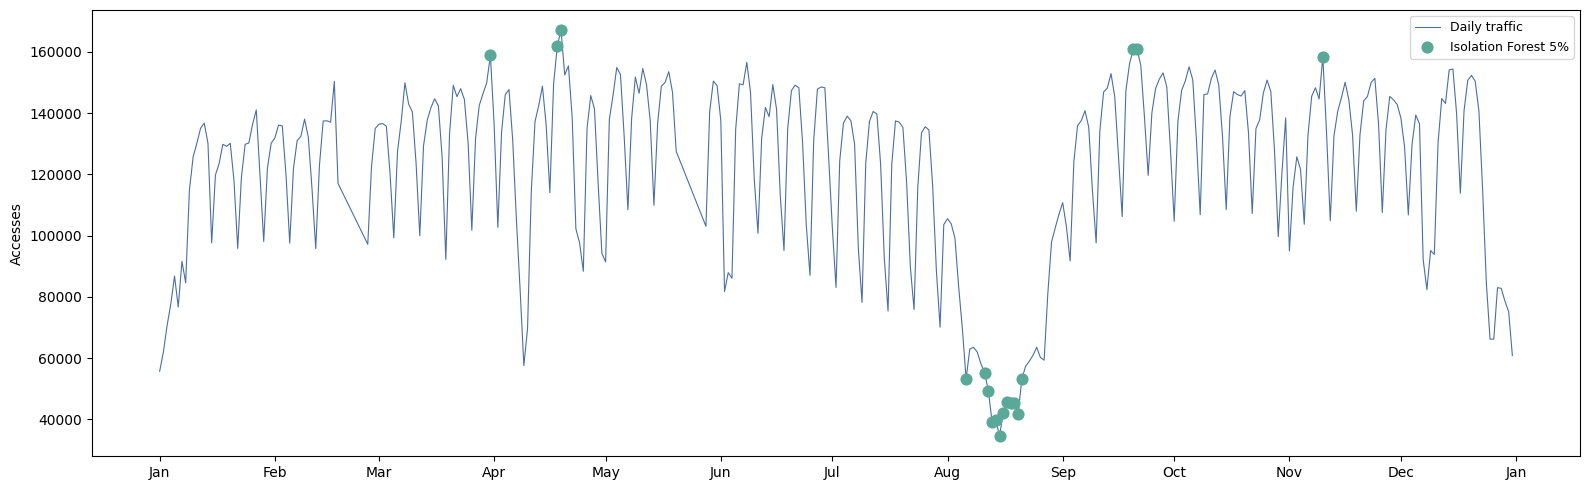

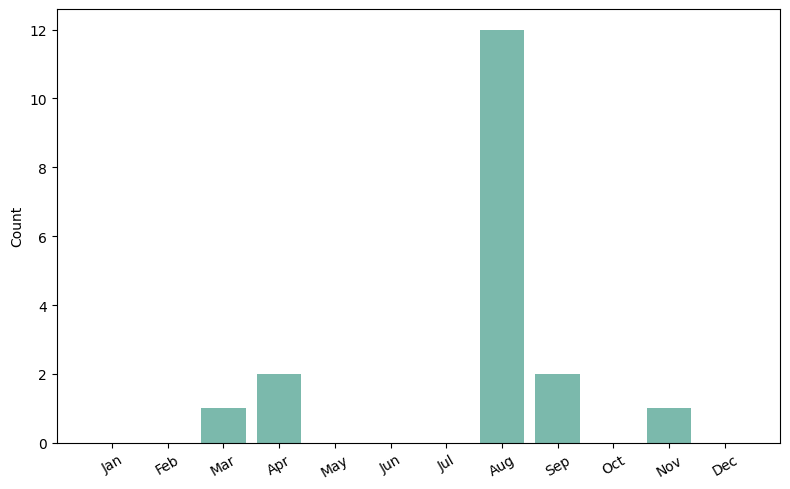

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))

contamination_label = f"Isolation Forest {CONTAMINATION*100:.0f}%"

ax.plot(anom_df.index, anom_df["traffic"], color=TRAFFIC_COLOR, linewidth=0.8, label="Daily traffic")
ax.scatter(if_outliers.index, if_outliers["traffic"],
                color=TRAFFIC_PRED, zorder=5, s=60, label=contamination_label)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel("Accesses")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'anomaly_isolation_forest.png'), dpi=150, bbox_inches='tight')
plt.show()

anom_df["dow_name"]   = anom_df.index.day_name()
anom_df["month_name"] = anom_df.index.month.map(MONTH_NAMES)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

if_month = (anom_df[anom_df["if_outlier"]]["month_name"].value_counts().reindex(list(MONTH_NAMES.values()), fill_value=0))
ax.bar(if_month.index, if_month.values, color=TRAFFIC_PRED, alpha=0.8)
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'anomaly_by_month.png'), dpi=150, bbox_inches='tight')
plt.show()
